# Introdução



Treinar redes neurais profundas do zero exige grandes volumes de dados e alto custo computacional. Uma alternativa eficiente é o **transfer learning**: reutilizar um modelo pré-treinado em uma tarefa de larga escala (ex: ImageNet com 1.2M imagens) como ponto de partida para uma nova tarefa. Pois assim o modelo já aprendeu um conhecimento geral que podemos utilizar para alguma tarefa específica de interesse.

Neste notebook aplicamos transfer learning com **MobileNetV2** para classificação de imagens meteorológicas, seguido de **fine-tuning** seletivo das camadas superiores da backbone.

O pipeline cobre:
- Carregamento e pré-processamento do dataset
- Transfer learning com backbone congelada
- Fine-tuning com descongelamento parcial
- Verificação dos resultados

paper da MobileNetV2: [link](https://arxiv.org/abs/1801.04381)

# Download from kaggle



O dataset utilizado é o [Weather Dataset](https://www.kaggle.com/datasets/jehanbhathena/weather-dataset), disponível no Kaggle. Ele contém imagens organizadas por classes meteorológicas (chuva, neve, sol, etc.).

O download é feito via `kagglehub` e o dataset é copiado para o diretório de trabalho do Colab.

source : https://www.kaggle.com/datasets/jehanbhathena/weather-dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jehanbhathena/weather-dataset")

print("Path to dataset files:", path)

100%|██████████| 587M/587M [00:28<00:00, 21.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jehanbhathena/weather-dataset/versions/3


In [ ]:
!pwd
import shutil
import os


# Caminho de destino
dest_path = "/content/weather-dataset"

shutil.copytree(path, dest_path)

print(f"Dataset copiado para: {dest_path}")

/content
Dataset copiado para: /content/weather-dataset


# Setup

Antes de treinar qualquer modelo, precisamos configurar o ambiente: importar bibliotecas, fixar seeds e definir hiperparâmetros.

**Seeds** garantem reprodutibilidade . Fixar `SEED=42` no NumPy, Python e TensorFlow faz com que resultados aleatórios (shuffle, inicialização de pesos, augmentação) sejam idênticos a cada execução.

Os **hiperparâmetros** centrais definidos aqui são:

- `IMG_SIZE = (224, 224)`: dimensão exigida pelo MobileNetV2, que foi treinado nesse tamanho.
- `BATCH_SIZE = 32`: quantas imagens são processadas por vez durante o treino.
- `EPOCHS = 20`: número máximo de passagens completas pelo dataset na fase de transfer learning.
- `LR = 0.001`: taxa de aprendizado inicial — controla o tamanho do passo na atualização dos pesos.
- `PATIENCE_ES = 10`: o treino para automaticamente se a métrica de validação não melhorar por 10 épocas consecutivas (*Early Stopping*).

In [ ]:
import os
import logging
import warnings
import numpy as np
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
PATH = "/content/weather-dataset/dataset"

EPOCHS       = 20
BATCH_SIZE   = 32
PATIENCE_ES  = 10
PATIENCE_REDUCELR_ON_PLATEAU = 3

MODEL_PATH   = "best_model.keras"
TFLITE_PATH  = "model_simple_int8.tflite"
MONITOR_MET  = "val_accuracy"
LR = 0.001

IMG_SIZE = (224, 224)
INPUT_SHAPE = (*IMG_SIZE, 3)

AUTOTUNE = tf.data.AUTOTUNE

# Dataset Load

Com o ambiente configurado, o próximo passo é carregar e preparar os dados para o treino.









---


O dataset é dividido em três subconjuntos: **treino**, **validação** e **teste**. O TensorFlow lê as imagens diretamente das pastas usando `image_dataset_from_directory`, que infere os rótulos automaticamente pelo nome de cada subpasta. O split 80/20 separa treino de validação; o conjunto de validação é então dividido ao meio, gerando validação e teste.


---


**Data Augmentation** é aplicada exclusivamente no conjunto de treino. A ideia é simples: ao espelhar, rotacionar e aplicar zoom nas imagens durante o treino, o modelo vê variações artificiais de cada exemplo — isso reduz overfitting e melhora a generalização.

O pré-processamento com `preprocess_input` do MobileNetV2 normaliza os pixels do intervalo `[0, 255]` para `[-1, 1]`, o formato esperado pela backbone pré-treinada. Aplicar essa mesma normalização usada no treino original do MobileNetV2 é fundamental — sem ela, os pesos pré-treinados produzem representações incorretas.


---


Por fim, `.cache()` e `.prefetch()` são otimizações de pipeline: o dataset é carregado em memória após a primeira época e as próximas imagens são preparadas em paralelo enquanto a GPU ainda está processando o batch atual, eliminando gargalos de I/O.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

])

def get_datasets(base_path):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base_path,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=True
    )


    val_test_ds = tf.keras.utils.image_dataset_from_directory(
        base_path,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=True
    )


    val_batches = tf.data.experimental.cardinality(val_test_ds)
    val_ds = val_test_ds.take(val_batches // 2)
    test_ds = val_test_ds.skip(val_batches // 2)

    return train_ds, val_ds, test_ds

def preprocess(image, label):
    return preprocess_input(image), label

def prepare_dataset(ds, is_training=False):
    ds = ds.cache()
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

raw_train_ds, raw_val_ds, raw_test_ds = get_datasets(PATH)
CLASS_NAMES = raw_train_ds.class_names

train_ds = prepare_dataset(raw_train_ds, is_training=True)
val_ds = prepare_dataset(raw_val_ds)
test_ds = prepare_dataset(raw_test_ds)

Found 6862 files belonging to 11 classes.
Using 5490 files for training.
Found 6862 files belonging to 11 classes.
Using 1372 files for validation.


Aqui podemos ver algumas imagens de amostragem do nosso dataset inicial carregado

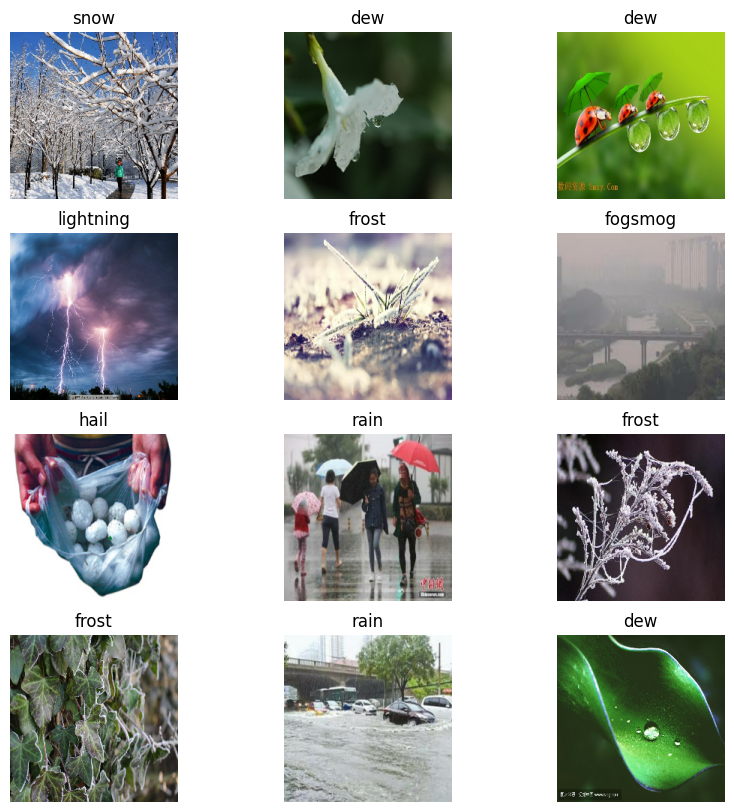

In [ ]:
def plot_samples(dataset, num_samples=12):
    class_names = dataset.class_names
    cols = 3
    rows = int(np.ceil(num_samples / cols))

    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(num_samples):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[np.argmax(labels[i])])
            plt.axis("off")
    plt.show()

plot_samples(raw_train_ds)

# Helpers

Funções auxiliares reutilizadas ao longo do notebook.

- **`get_callbacks()`**: retorna os três callbacks usados no treino:
  - *EarlyStopping*: interrompe o treino se a validação parar de melhorar, evitando overfitting e desperdício de tempo.
  - *ModelCheckpoint*: salva automaticamente o melhor modelo em disco com base na `val_accuracy`.
  - *ReduceLROnPlateau*: reduz a taxa de aprendizado quando a validação estagna , útil para escapar de mínimos locais.

- **`plot_history()`**: plota as curvas de loss e accuracy de treino e validação ao longo das épocas , principal ferramenta visual para diagnosticar overfitting ou underfitting.

- **`evaluate_model()`**: avalia o modelo no conjunto de teste e reporta a acurácia final.

- **`predict_random_samples()`**: visualiza predições em amostras aleatórias do dataset, exibindo rótulo real e predito. Corretos em verde, erros em vermelho.

In [ ]:
def get_callbacks():
    return [
        EarlyStopping(monitor=MONITOR_MET, patience=PATIENCE_ES, verbose=0, restore_best_weights=True),
        ModelCheckpoint(MODEL_PATH,   monitor=MONITOR_MET, save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor=MONITOR_MET, factor=0.1, patience=PATIENCE_REDUCELR_ON_PLATEAU, min_lr=1e-6, verbose=1)
    ]

def plot_history(history):
    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

def evaluate_model(model, test_data, y_test=None):
    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"Acurácia final no test set: {acc:.4f}")
    return loss, acc

def predict_random_samples(model, dataset, class_names, num_samples=10):
    plt.figure(figsize=(15, 6))

    subset = dataset.unbatch().shuffle(buffer_size=1000, seed=None).take(num_samples)

    images = []
    true_labels = []

    for img, lbl in subset:
        images.append(img.numpy())
        true_labels.append(np.argmax(lbl.numpy()))

    images_arr = np.array(images)
    predictions = model.predict(images_arr, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)

    rows = int(np.ceil(np.sqrt(num_samples)))
    cols = int(np.ceil(num_samples / rows))

    if num_samples == 10:
        rows, cols = 2, 5

    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        img_display = ((images_arr[i] + 1) * 127.5).clip(0, 255).astype("uint8")

        plt.imshow(img_display)

        is_correct = true_labels[i] == pred_labels[i]
        color = 'green' if is_correct else 'red'

        label_true = class_names[true_labels[i]]
        label_pred = class_names[pred_labels[i]]

        plt.title(f"T: {label_true}\nP: {label_pred}", color=color, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()



# Model

Aqui definimos a arquitetura do modelo utilizando transfer learning com MobileNetV2.

**MobileNetV2** é uma rede neural convolucional pré-treinada no ImageNet , um dataset com mais de 1 milhão de imagens e 1000 classes. Isso significa que ela já aprendeu a identificar padrões visuais úteis como bordas, texturas e formas. Em vez de aprender tudo do zero, aproveitamos esse conhecimento.

A arquitetura segue o padrão clássico de transfer learning:

1. **Backbone congelada** (`base_model.trainable = False`): os pesos do MobileNetV2 são mantidos fixos. A rede é usada apenas como extrator de features , ela transforma cada imagem em um vetor de características compacto.
2. **GlobalAveragePooling2D**: reduz o mapa de features espacial a um único vetor, diminuindo drasticamente o número de parâmetros.
3. **BatchNormalization + Dropout**: estabilizam o treino e reduzem overfitting.
4. **Dense de saída**: camada final com `softmax`, produzindo uma probabilidade por classe. É a única parte treinada do zero.

O otimizador **AdamW** combina Adam com *weight decay*, uma forma de regularização que penaliza pesos muito grandes, contribuindo para melhor generalização.

In [ ]:
def create_balanced_model():
    inputs = tf.keras.Input(shape=INPUT_SHAPE)

    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=INPUT_SHAPE
    )
    base_model.trainable = False

    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

## Compilação do Modelo

Com a arquitetura definida, o próximo passo é compilar o modelo antes de treinar.

`model.compile()` configura três elementos essenciais:

**Otimizador (AdamW)**: algoritmo responsável por atualizar os pesos da rede a cada batch. O `learning_rate=0.001` define o tamanho do passo nessa atualização.

**Loss (categorical_crossentropy)**: função que mede o erro entre a predição do modelo e o rótulo real. O objetivo do treino é minimizar esse valor. Usamos a versão categórica pois temos múltiplas classes.

**Métricas**: `accuracy` é exibida durante o treino para acompanhar o desempenho de forma interpretável, mas não influencia a otimização diretamente.

`model.summary()` exibe um resumo da arquitetura com o número de parâmetros de cada camada. Observe que a grande maioria dos parâmetros está marcada como **non-trainable**, pois a backbone está congelada.

In [ ]:
print("Creating model...")
model = create_balanced_model()
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LR, weight_decay=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    jit_compile=False
)
model.summary()

Creating model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,195 (8.69 MB)

 Trainable params: 16,651 (65.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

# Train


Com o modelo compilado, iniciamos a primeira fase do treino: transfer learning com backbone congelada.

`model.fit()` itera sobre o dataset de treino por até `EPOCHS=20` épocas, avaliando no conjunto de validação ao final de cada uma. Os callbacks definidos anteriormente atuam automaticamente durante esse processo, interrompendo o treino se necessário e salvando o melhor modelo.

Nessa fase, apenas os pesos das camadas adicionadas (pooling, batch norm, dropout e dense) são atualizados. A backbone permanece congelada, funcionando como um extrator de features fixo.

O objetivo aqui é treinar a "cabeça" do modelo para mapear as features extraídas pelo MobileNetV2 para as classes do nosso dataset antes de qualquer ajuste fino nos pesos da backbone.

In [ ]:
print(f"\n Starting training - {EPOCHS} epochs (batch size={BATCH_SIZE})")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=get_callbacks(),
    verbose=1
)



 Starting training - 20 epochs (batch size=32)
Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.5112 - loss: 1.5299 - val_accuracy: 0.7827 - val_loss: 0.6991 - learning_rate: 0.0010
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.7692 - loss: 0.6777 - val_accuracy: 0.7961 - val_loss: 0.6389 - learning_rate: 0.0010
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.8066 - loss: 0.5756 - val_accuracy: 0.7932 - val_loss: 0.6259 - learning_rate: 0.0010
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.8156 - loss: 0.5450 - val_accuracy: 0.8185 - val_loss: 0.5874 - learning_rate: 0.0010
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.8155 - loss: 0.5534 - val_accuracy: 0.8185 - val_loss: 0.5726 - learning_rate: 0.0010
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.8407 - loss: 0.4832 - val_accuracy: 0.8229 - val_loss: 0.5717 - learning_rate: 0.0010
Epoch 7/20
172/172 ━━━━━━━━━

In [ ]:
print("\n Evaluating on test set after initial transfer learning")
evaluate_model(model, test_ds, None)
print(f"Number of classes {len(CLASS_NAMES)}"  )


 Evaluating on test set after initial transfer learning
Acurácia final no test set: 0.8200
Number of classes 11


# Fine Tuning

Após a fase inicial, a backbone estava completamente congelada e apenas a cabeça do modelo foi treinada. O fine-tuning é a segunda fase: descongelamos parte da backbone e treinamos o modelo inteiro com uma taxa de aprendizado muito menor.

`FINE_TUNE_AT = 100` define o ponto de corte: todas as camadas abaixo desse índice permanecem congeladas, e apenas as camadas superiores da backbone são liberadas para atualização. As camadas iniciais de uma CNN capturam padrões genéricos (bordas, texturas) que são universais e não precisam ser ajustadas. As camadas superiores capturam padrões mais específicos, que se beneficiam do ajuste para o nosso domínio.

O `learning_rate=1e-5` é deliberadamente muito menor que o usado na fase anterior. Isso é essencial: atualizar pesos pré-treinados com um learning rate alto destrói o conhecimento já aprendido no ImageNet, fenômeno chamado de **catastrophic forgetting**.

O treino continua de onde parou (`initial_epoch=len(history.epoch)`), mantendo a continuidade das curvas de aprendizado.

In [ ]:
FINE_TUNE_LR     = 1e-5
FINE_TUNE_EPOCHS = 10
FINE_TUNE_AT     = 100  # descongelar a partir dessa camada

base_model = model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=FINE_TUNE_LR, weight_decay=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

total_epochs = EPOCHS + FINE_TUNE_EPOCHS

In [ ]:
history_fine = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=len(history.epoch),
    validation_data=val_ds,
    callbacks=get_callbacks(),
    verbose=1
)

Epoch 21/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 72s 213ms/step - accuracy: 0.7709 - loss: 0.6643 - val_accuracy: 0.8140 - val_loss: 0.6549 - learning_rate: 1.0000e-05
Epoch 22/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.8045 - loss: 0.5528 - val_accuracy: 0.8065 - val_loss: 0.6812 - learning_rate: 1.0000e-05
Epoch 23/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.8153 - loss: 0.5445 - val_accuracy: 0.8274 - val_loss: 0.6425 - learning_rate: 1.0000e-05
Epoch 24/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.8294 - loss: 0.4874 - val_accuracy: 0.8393 - val_loss: 0.5674 - learning_rate: 1.0000e-05
Epoch 25/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.8304 - loss: 0.4882 - val_accuracy: 0.8452 - val_loss: 0.5491 - learning_rate: 1.0000e-05
Epoch 26/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.8370 - loss: 0.4503 - val_accuracy: 0.8452 - val_loss: 0.5489 - learning_rate: 1.0000e-05
Epoch 27/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 

# Results



Após as duas fases de treino, avaliamos o modelo no conjunto de teste , que são dados que o modelo nunca viu durante o treino.

**Transfer Learning (backbone congelada):** acurácia de **82.00%**

**Fine-tuning (backbone parcialmente descongelada):** acurácia de **84.43%**

O ganho de ~2.4 pontos percentuais confirma o efeito do fine-tuning: ao ajustar as camadas superiores da backbone para o domínio específico de imagens meteorológicas, o modelo extrai features mais relevantes para a tarefa.

As curvas de loss e accuracy plotadas em seguida permitem verificar o comportamento do treino ao longo das épocas, identificando sinais de overfitting ou underfitting em cada fase.

In [ ]:
print("\n Evaluating on test set after fine tuning")
evaluate_model(model, test_ds, None)
print(f"Number of classes {len(CLASS_NAMES)}"  )


 Evaluating on test set after fine tuning
Acurácia final no test set: 0.8443
Number of classes 11



 Plotting training curve


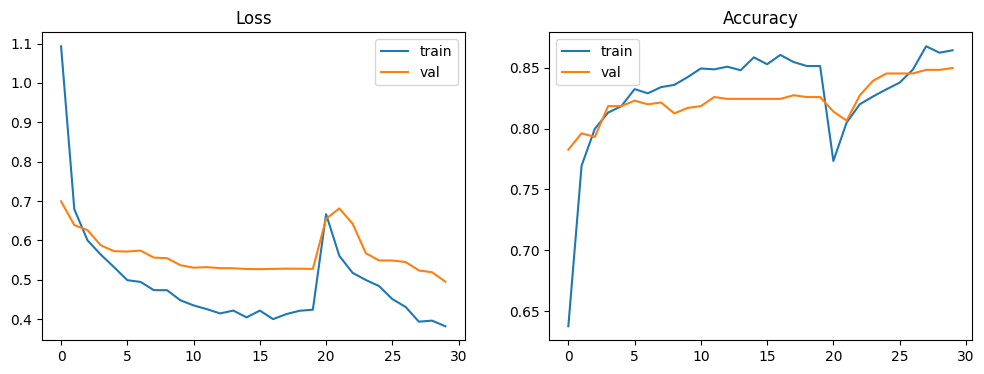

In [ ]:
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    h1.history = merged
    return h1

print("\n Plotting training curve")

full_history = merge_histories(history, history_fine)
plot_history(full_history)

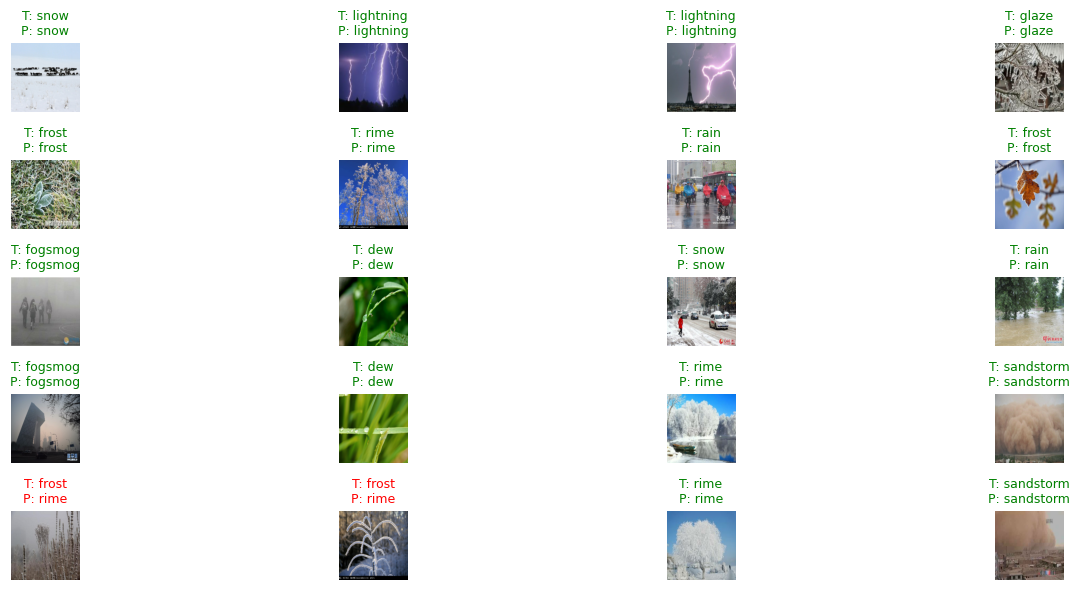

In [ ]:
predict_random_samples(model, test_ds, CLASS_NAMES, num_samples=20)